<a id="top"></a>
# Chapter 1 — The memristor as a state-controlled resistor

**MemrisTec Compact Models — Memristor Physics from Paper to Code** · chapter 1 of 6

[◀ 0 Introduction](Memristec_00_Introduction.ipynb) · [Contents of the book](README.md) · [2 Linear ion drift and window functions ▶](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb)

**In this chapter**

- [§1 What a memristor is](#sec-1)
- [§2 The pinched hysteresis loop and its frequency dependence](#sec-2)
- [§3 Memristance is a function of charge](#sec-3)
- [§4 The dynamic route map](#sec-4)

All chapters: [0](Memristec_00_Introduction.ipynb) · [1](Memristec_01_State_Controlled_Resistor.ipynb) · [2](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [3](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [4](Memristec_04_Filamentary_Switching.ipynb) · [5](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [6](Memristec_06_Benchmarking_and_the_Library.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–26), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down)
for _cand in ("scripts", os.path.join("..", "scripts")):
    if os.path.isfile(os.path.join(_cand, "memristec_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import memristec_tools as mt
from memristec_tools import (LinearIonDrift, Yakopcic2013, VTEAM2015, StanfordPKU2016, MODELS,
                             simulate, iv_sweep, loop_metrics, dynamic_route_map,
                             pulse_train, pulse_response, sine, triangular, rectangular)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 0}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("memristec-skill", mt.__version__, "| numpy", np.__version__, "| chapter 1")
t_chapter_start = time.time()

memristec-skill 0.2.0 | numpy 2.5.2 | chapter 1


<a id="sec-1"></a>

## 1. What a memristor is

Chua (1971) noticed that the four circuit variables — charge $q$, flux $\varphi$, current $i$ and
voltage $v$ — admit six pairwise relations, of which five had a component: the resistor
($v$–$i$), the capacitor ($q$–$v$), the inductor ($\varphi$–$i$), and the two definitions
$i = \dot q$, $v = \dot\varphi$. The missing one, $\varphi$–$q$, defines the **memristor**:
$v = M(q)\, i$, a resistance that depends on the charge that has flowed through it. Chua and
Kang (1976) generalised this to **memristive systems**,

$$ v = R(x)\, i, \qquad \dot x = f(x, i) \quad\text{or}\quad \dot x = f(x, v), $$

a resistor whose value follows an internal state $x$ that the current or voltage history
drives. Strukov, Snider, Stewart and Williams (2008) found this behaviour in a TiO$_2$ film:
the doped fraction $x = w/D$ of the film sets the resistance
$R(x) = R_{\rm on} x + R_{\rm off}(1-x)$, and the current moves the dopants,
$\dot x = k\, i$ with $k = \mu_v R_{\rm on}/D^2$. This chapter uses that model with no window
function (`window="none"`); chapter 2 adds the windows.

Every model in this book is a memristive system with one state $x \in [0, 1]$, two functions
`state_derivative(x, v)` and `current(x, v)`, and one shared integrator (`simulate`).

linear_ion_drift {'R_on': 100.0, 'R_off': 16000.0, 'D': 1e-08, 'mu_v': 1e-14, 'p': 10, 'j': 1.0, 'x0': 0.1}


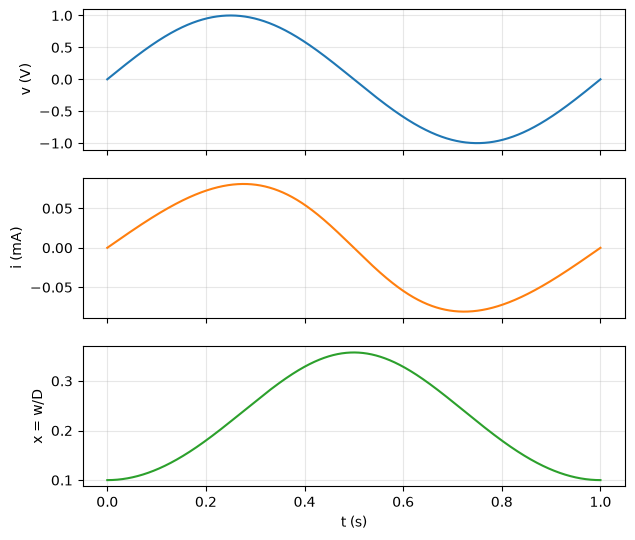

[PASS] current vanishes where the voltage vanishes (t = 0, T/2, T)
[PASS] x rises on the positive half-cycle and falls on the negative one
[PASS] the state returns close to where it started after one period — x(T) - x(0) = +0.0000


True

In [2]:
m = LinearIonDrift(window="none")            # Strukov 2008, R_on = 100 Ω, R_off = 16 kΩ, x0 = 0.1
print(m.name, m.params)
res = iv_sweep(m, 1.0, 1.0, cycles=1, n_per_cycle=4000)     # 1 V, 1 Hz sine, one period

fig, axes = plt.subplots(3, 1, figsize=(7, 6.2), sharex=True)
axes[0].plot(res.t, res.v, color="C0"); axes[0].set_ylabel("v (V)")
axes[1].plot(res.t, 1e3 * res.i, color="C1"); axes[1].set_ylabel("i (mA)")
axes[2].plot(res.t, res.x, color="C2"); axes[2].set_ylabel("x = w/D"); axes[2].set_xlabel("t (s)")
show(fig)
caption("Linear ion drift without a window under a 1 V, 1 Hz sine: the current follows the "
        "voltage through a resistance that itself follows the state x, which the current pushes "
        "up on the positive half-cycle and back down on the negative one.")

half = len(res.t) // 2
check("current vanishes where the voltage vanishes (t = 0, T/2, T)",
      abs(res.i[0]) < 1e-9 and abs(res.i[half]) < 1e-9 and abs(res.i[-1]) < 1e-9)
check("x rises on the positive half-cycle and falls on the negative one",
      res.x[half] > res.x[0] and res.x[-1] < res.x[half])
check("the state returns close to where it started after one period", abs(res.x[-1] - res.x[0]) < 0.02,
      f"x(T) - x(0) = {res.x[-1] - res.x[0]:+.4f}")

<a id="sec-2"></a>

## 2. The pinched hysteresis loop and its frequency dependence

Plot $i$ against $v$ and the memristor shows its fingerprint (Chua 2011): a **pinched
hysteresis loop** — the curve passes through the origin whatever the amplitude, because
$i = v/R(x)$ vanishes with $v$, and it has two lobes because $x$ differs on the way up and on
the way down. As the frequency rises the state has less time to move within a period, the
lobes shrink, and the loop collapses to the straight line of a fixed resistor.
`loop_metrics` measures the lobe area (the sum of the two lobes' areas), the pinching, and
the extreme resistances.

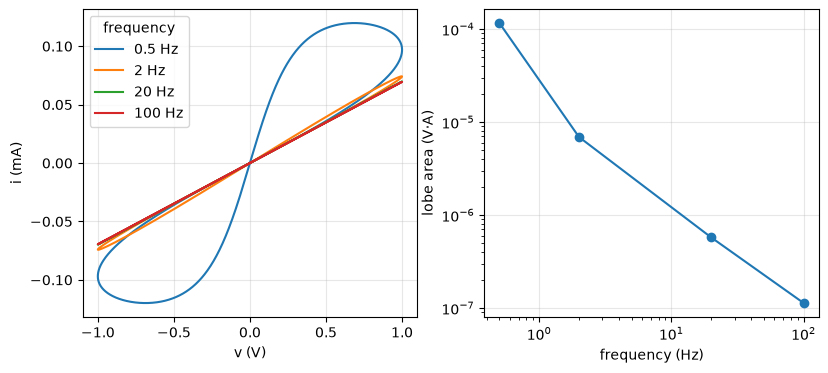

[PASS] every loop passes through the origin (pinched)
[PASS] lobe area decreases monotonically with frequency — 1.16e-04, 6.90e-06, 5.74e-07, 1.13e-07
[PASS] area at 100 Hz is below 1 % of the area at 0.5 Hz — ratio = 9.75e-04
[PASS] at 100 Hz the resistance barely moves (R_max/R_min < 1.05) — 1.002
[PASS] at 0.5 Hz it moves by more than a factor 2 — 6.31


True

In [3]:
freqs = [0.5, 2.0, 20.0, 100.0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
areas, ratios = [], []
for f in freqs:
    r = iv_sweep(LinearIonDrift(window="none"), 1.0, f, cycles=1, n_per_cycle=4000)
    met = loop_metrics(r)
    areas.append(met["area"]); ratios.append(met["r_max"] / met["r_min"])
    ax1.plot(r.v, 1e3 * r.i, label=f"{f:g} Hz")
ax1.set_xlabel("v (V)"); ax1.set_ylabel("i (mA)"); ax1.legend(title="frequency")
ax2.loglog(freqs, areas, "o-"); ax2.set_xlabel("frequency (Hz)"); ax2.set_ylabel("lobe area (V·A)")
show(fig)
caption("Left: pinched hysteresis loops of the same device at 0.5, 2, 20 and 100 Hz (1 V sine). "
        "Right: the summed lobe area against frequency — it falls monotonically and the loop "
        "degenerates into the line of a fixed resistor at high frequency.")

check("every loop passes through the origin (pinched)",
      all(loop_metrics(iv_sweep(LinearIonDrift(window='none'), 1.0, f, cycles=1, n_per_cycle=4000))["pinched_at_origin"]
          for f in freqs))
check("lobe area decreases monotonically with frequency", all(a > b for a, b in zip(areas, areas[1:])),
      ", ".join(f"{a:.2e}" for a in areas))
check("area at 100 Hz is below 1 % of the area at 0.5 Hz", areas[-1] / areas[0] < 0.01,
      f"ratio = {areas[-1] / areas[0]:.2e}")
check("at 100 Hz the resistance barely moves (R_max/R_min < 1.05)", ratios[-1] < 1.05, f"{ratios[-1]:.3f}")
check("at 0.5 Hz it moves by more than a factor 2", ratios[0] > 2.0, f"{ratios[0]:.2f}")

<a id="sec-3"></a>

## 3. Memristance is a function of charge

Without a window, $\dot x = k\,i$ integrates to $x(t) = x_0 + k\,q(t)$ with
$q(t) = \int_0^t i\,dt'$, so the resistance is an *affine function of the charge*,

$$ M(q) = R_{\rm off} - (R_{\rm off} - R_{\rm on})\,(x_0 + k q), $$

which is Strukov's eq. 6 and the literal Chua memristor $v = M(q)\,i$. The check below
integrates the simulated current and compares $x(t)$ with $x_0 + k q(t)$: the two agree to the
integrator's accuracy, so the state variable *is* the charge in disguise. Any window function
(chapter 2) breaks this exact statement, which is why "memristance" is then a function of the
state, not of the charge alone.

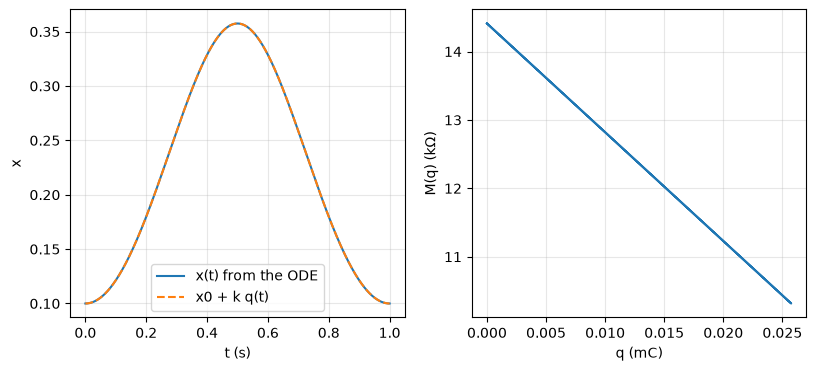

[PASS] x(t) = x0 + k q(t) to better than 1e-6 — max deviation 6.0e-09
[PASS] dM/dq = -(R_off - R_on) k within 0.1 % — slope -1.5900e+08 Ω/C


True

In [4]:
m = LinearIonDrift(window="none")
res = iv_sweep(m, 1.0, 1.0, cycles=1, n_per_cycle=4000)
q = np.concatenate([[0.0], np.cumsum(0.5 * (res.i[1:] + res.i[:-1]) * np.diff(res.t))])   # trapezoid
x_from_q = m.x0 + m.k * q
R = np.array([m.resistance(x) for x in res.x])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
ax1.plot(res.t, res.x, label="x(t) from the ODE"); ax1.plot(res.t, x_from_q, "--", label="x0 + k q(t)")
ax1.set_xlabel("t (s)"); ax1.set_ylabel("x"); ax1.legend()
ax2.plot(1e3 * q, R / 1e3); ax2.set_xlabel("q (mC)"); ax2.set_ylabel("M(q) (kΩ)")
show(fig)
caption("Left: the state from the ODE and the state reconstructed from the integrated charge "
        "coincide. Right: the memristance against charge is a straight line — Strukov's affine "
        "law, the charge-controlled memristor of Chua 1971.")

err = np.max(np.abs(res.x - x_from_q))
check("x(t) = x0 + k q(t) to better than 1e-6", err < 1e-6, f"max deviation {err:.1e}")
slope = np.polyfit(q, R, 1)[0]
check("dM/dq = -(R_off - R_on) k within 0.1 %",
      abs(slope + (m.params['R_off'] - m.params['R_on']) * m.k) < 1e-3 * (m.params['R_off'] - m.params['R_on']) * m.k,
      f"slope {slope:.4e} Ω/C")

<a id="sec-4"></a>

## 4. The dynamic route map

Chua's **dynamic route map** (DRM) plots $\dot x$ against $x$ for a set of constant voltages.
Every trajectory of the state under that voltage is a walk along the curve: $x$ moves right
where $\dot x > 0$, left where $\dot x < 0$, and stops at the zeros. For the linear ion drift
model $\dot x = k\,v/R(x)$: the sign is the sign of $v$, and the speed grows with $x$ because the
resistance falls as the doped region widens. There is no dead zone and no fixed point inside
$(0, 1)$ — every non-zero voltage moves the state, however small. Chapters 3 and 4 show DRMs
with thresholds and boundaries.

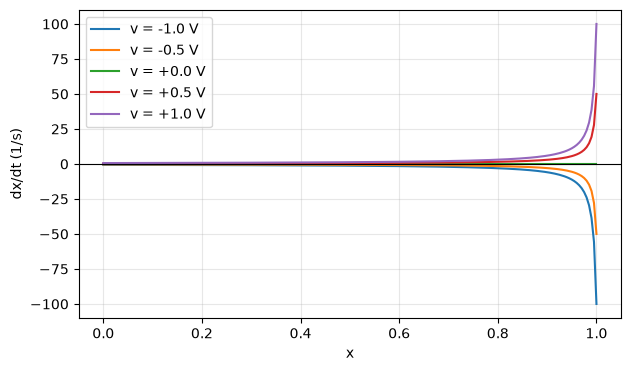

[PASS] dx/dt has the sign of v everywhere inside (0, 1)
[PASS] the rate at x = 0.9 exceeds the rate at x = 0.1 for the same voltage — 5.917 vs 0.694 1/s
[PASS] dx/dt = k v / R(x) exactly


True

In [5]:
xs = np.linspace(0.0, 1.0, 201)
drm = dynamic_route_map(LinearIonDrift(window="none"), xs, [-1.0, -0.5, 0.0, 0.5, 1.0])

fig, ax = plt.subplots()
for v, rate in drm.items():
    ax.plot(xs, rate, label=f"v = {v:+.1f} V")
ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("x"); ax.set_ylabel("dx/dt (1/s)"); ax.legend()
show(fig)
caption("Dynamic route map of the linear ion drift model without a window: dx/dt against x at "
        "five constant voltages. The sign follows the voltage, the magnitude grows with x as the "
        "resistance drops, and there is no dead band.")

check("dx/dt has the sign of v everywhere inside (0, 1)",
      np.all(drm[1.0][1:-1] > 0) and np.all(drm[-1.0][1:-1] < 0) and np.all(drm[0.0] == 0))
check("the rate at x = 0.9 exceeds the rate at x = 0.1 for the same voltage", drm[1.0][180] > drm[1.0][20],
      f"{drm[1.0][180]:.3f} vs {drm[1.0][20]:.3f} 1/s")
m0 = LinearIonDrift(window="none")
check("dx/dt = k v / R(x) exactly", np.allclose(drm[0.5], m0.k * 0.5 / np.array([m0.resistance(x) for x in xs])))

### Exercises for chapter 1

**1.1** Drive the same device with a triangular wave of the same amplitude and frequency. Is
the loop still pinched? Does its area differ from the sine's, and why?

**1.2** Raise $R_{\rm off}/R_{\rm on}$ from 160 to 1000 (keep $R_{\rm on}$). What happens to the
asymmetry of the two lobes and to the maximum current?

Worked solutions follow.

[PASS] 1.1 triangular loop is pinched: zero current at both zero crossings
[PASS] 1.1 the triangle's area is smaller than the sine's but of the same order — sine 1.786e-05, triangle 6.713e-06 V·A, ratio 0.38


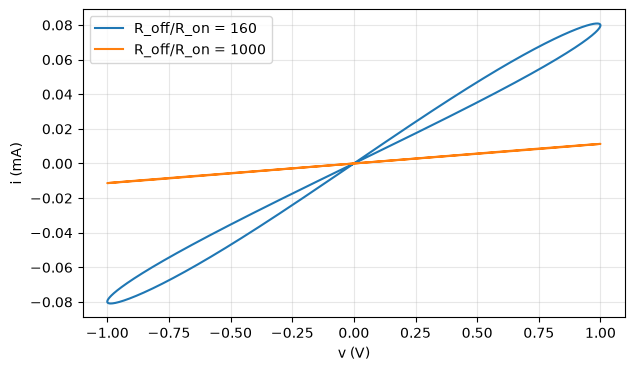

[PASS] 1.2 asymmetry |i_max|/|i_min| grows with the ratio


True

In [6]:
# 1.1 — triangular drive: still pinched (i = v / R(x) vanishes with v). The triangle starts at -A and
#       crosses zero at T/4 and 3T/4, which are grid points here, so the current is exactly zero there.
#       Its area is smaller (measured 0.38 of the sine's): the mean |v| of a triangle is A/2 against
#       2A/π for a sine, so less charge flows per half-cycle and the state moves less.
r_sin = iv_sweep(LinearIonDrift(window="none"), 1.0, 1.0, cycles=1, n_per_cycle=4000, stimulus="sin")
r_tri = iv_sweep(LinearIonDrift(window="none"), 1.0, 1.0, cycles=1, n_per_cycle=4000, stimulus="triangular")
a_sin, a_tri = loop_metrics(r_sin)["area"], loop_metrics(r_tri)["area"]
check("1.1 triangular loop is pinched: zero current at both zero crossings",
      abs(r_tri.i[1000]) < 1e-12 and abs(r_tri.i[3000]) < 1e-12 and abs(r_tri.v[1000]) < 1e-12)
check("1.1 the triangle's area is smaller than the sine's but of the same order",
      0.25 < a_tri / a_sin < 1.0, f"sine {a_sin:.3e}, triangle {a_tri:.3e} V·A, ratio {a_tri / a_sin:.2f}")

# 1.2 — larger R_off/R_on: the positive lobe (low R) carries far more current than the negative one
r_big = iv_sweep(LinearIonDrift(window="none", R_off=100e3), 1.0, 1.0, cycles=1, n_per_cycle=4000)
m_small, m_big = loop_metrics(r_sin), loop_metrics(r_big)
fig, ax = plt.subplots()
ax.plot(r_sin.v, 1e3 * r_sin.i, label="R_off/R_on = 160"); ax.plot(r_big.v, 1e3 * r_big.i, label="R_off/R_on = 1000")
ax.set_xlabel("v (V)"); ax.set_ylabel("i (mA)"); ax.legend()
show(fig)
caption("Exercise 1.2: the pinched loop for two resistance ratios. A larger R_off/R_on makes the "
        "state's excursion matter more, the lobes more asymmetric and the peak current smaller "
        "because the device starts (x0 = 0.1) closer to R_off.")
check("1.2 asymmetry |i_max|/|i_min| grows with the ratio",
      m_big["i_max"] / abs(m_big["i_min"]) > m_small["i_max"] / abs(m_small["i_min"]))

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 1 — checks passed : {_CHECKS['pass']}")
print(f"chapter 1 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 1 — checks passed : 16
chapter 1 — checks failed : 0
wall time                 : 3 s
Every quantitative claim in this notebook was verified in this run.
